# Proyek Klasifikasi Gambar
Nama: Tariq Ahmad

# **IMPORT Libraries yang diperlukan**

In [ ]:
!pip install split-folders tensorflowjs
import os
import matplotlib.pyplot as plt
import splitfolders
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub

# **Load Dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [ ]:
import os
import splitfolders

inputdir = os.path.join(path, "PetImages")
outputdir = '/content/pet_images_split'

splitfolders.ratio(inputdir, output=outputdir, seed=42, ratio=(.7, .15, .15), group_prefix=None)
print("Selesai membagi folder ke:", outputdir)

Copying files: 25002 files [01:59, 208.55 files/s]

Selesai membagi folder ke: /content/pet_images_split


In [ ]:
import tensorflow as tf

print("Memulai pembersihan file korup di folder split...")
num_skipped = 0

for split in ('train', 'val', 'test'):
    for folder_name in ("Cat", "Dog"):
        folder_path = os.path.join(outputdir, split, folder_name)

        if not os.path.exists(folder_path):
            continue

        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)

            if not os.path.isfile(fpath):
                continue

            try:
                with open(fpath, "rb") as fobj:
                    is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
            except Exception:
                is_jfif = False


            if not is_jfif:
                num_skipped += 1
                os.remove(fpath)

print(f"Selesai! Berhasil menghapus {num_skipped} file rusak dari folder training/validation/test.")

Memulai pembersihan file korup di folder split...
Selesai! Berhasil menghapus 1590 file rusak dari folder training/validation/test.


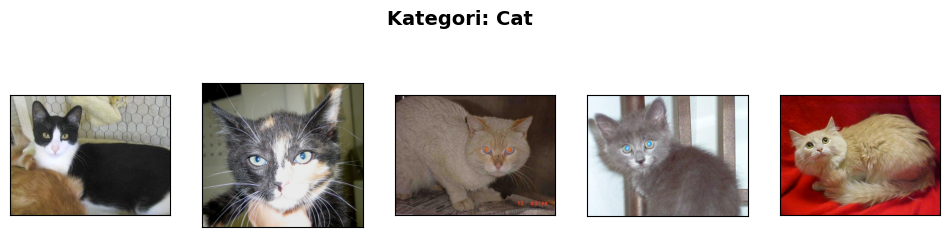

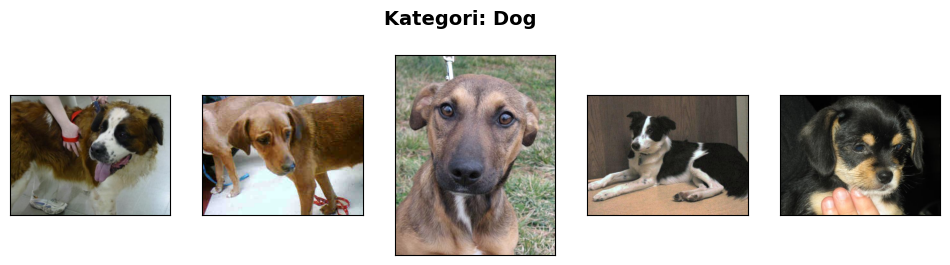

In [18]:
import os
import matplotlib.pyplot as plt

train_dataset_path = '/content/pet_images_split/train'

for category in os.listdir(train_dataset_path):
    category_path = os.path.join(train_dataset_path, category)

    if not os.path.isdir(category_path):
        continue

    images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:5]

    if not images:
        print(f"Tidak ada gambar yang ditemukan di kategori: {category}")
        continue

    plt.figure(figsize=(12, 3))
    plt.suptitle(f"Kategori: {category}", fontsize=14, weight='bold')

    for j in range(len(images)):
        img_path = os.path.join(category_path, images[j])

        plt.subplot(1, 5, j+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        # Baca dan tampilkan gambar
        img = plt.imread(img_path)
        plt.imshow(img)

    plt.show()

# **Data Preprocessing**

In [ ]:
for i in ['test', 'val', 'train']:
  for j in os.listdir(os.path.join(outputdir, i)):
    kategori_path = os.path.join(outputdir, i, j)
    hitung = len(os.listdir(kategori_path))
    print(f'Split: {i}, Kategori: {j}, Jumlah: {hitung}')

Split: test, Kategori: Cat, Jumlah: 1780
Split: test, Kategori: Dog, Jumlah: 1736
Split: val, Kategori: Cat, Jumlah: 1765
Split: val, Kategori: Dog, Jumlah: 1741
Split: train, Kategori: Cat, Jumlah: 8197
Split: train, Kategori: Dog, Jumlah: 8193


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


traindir = os.path.join(outputdir, 'train')
valdir = os.path.join(outputdir, 'val')
testdir = os.path.join(outputdir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)

valtest_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    traindir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = valtest_datagen.flow_from_directory(
    valdir,
    target_size=(150, 150),
    batch_size=32,
    shuffle=False,
    class_mode='binary'
)

test_generator = valtest_datagen.flow_from_directory(
    testdir,
    target_size=(150, 150),
    batch_size=32,
    shuffle=False,
    class_mode='binary'
)

Found 16388 images belonging to 2 classes.
Found 3506 images belonging to 2 classes.
Found 3516 images belonging to 2 classes.


In [ ]:
jumlah_class = len(train_generator.class_indices)
print("Banyak kelas: ", jumlah_class)

Banyak kelas:  2


# **Modelling**

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.95):
            print("\nAkurasi training & validasi > 95%, hentikan training lebih awal!")
            self.model.stop_training = True

accuracy_threshold = myCallback()


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

model = tf.keras.models.Sequential([
    # Blok 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    # Blok 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Blok 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.optimizers.Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model.summary()

print("Memulai proses training dataset Cats & Dogs...")
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    verbose=1,
    callbacks=[accuracy_threshold, reduce_lr, early_stop]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,425 (497.75 KB)

 Trainable params: 126,977 (496.00 KB)

 Non-trainable params: 448 (1.75 KB)

Memulai proses training dataset Cats & Dogs...
Epoch 1/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 137s 247ms/step - accuracy: 0.6076 - loss: 0.6589 - val_accuracy: 0.6058 - val_loss: 0.6593 - learning_rate: 5.0000e-04
Epoch 2/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 124s 241ms/step - accuracy: 0.6490 - loss: 0.6206 - val_accuracy: 0.6075 - val_loss: 0.7449 - learning_rate: 5.0000e-04
Epoch 3/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 118s 230ms/step - accuracy: 0.6881 - loss: 0.5829 - val_accuracy: 0.6754 - val_loss: 0.6278 - learning_rate: 5.0000e-04
Epoch 4/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 117s 228ms/step - accuracy: 0.7212 - loss: 0.5510 - val_accuracy: 0.6851 - val_loss: 0.6091 - learning_rate: 5.0000e-04
Epoch 5/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.7308 - loss: 0.5303 - val_accuracy: 0.6087 - val_loss: 1.3224 - learning_rate: 5.0000e-04
Epoch 6/50
513/513 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - accuracy: 0.7575 - loss: 0.5026 - val_accuracy: 0.7570 - val_loss: 0.4973 - learning_rate: 5.00

(Training berhenti secara insidental, kemungkinan kesalahan auto-saving dari google colab)

In [ ]:
print("\n1. Evaluasi pada Validation Set")
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f"Akurasi Validation Set: {val_accuracy * 100:.2f}%")
print("\n1. Evaluasi pada Test Set")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print(f"Akurasi Test Set: {test_accuracy * 100:.2f}%")


1. Evaluasi pada Validation Set
Akurasi Validation Set: 90.39%

1. Evaluasi pada Test Set
Akurasi Test Set: 90.44%


# **Plot Akurasi dan Loss dari Model**

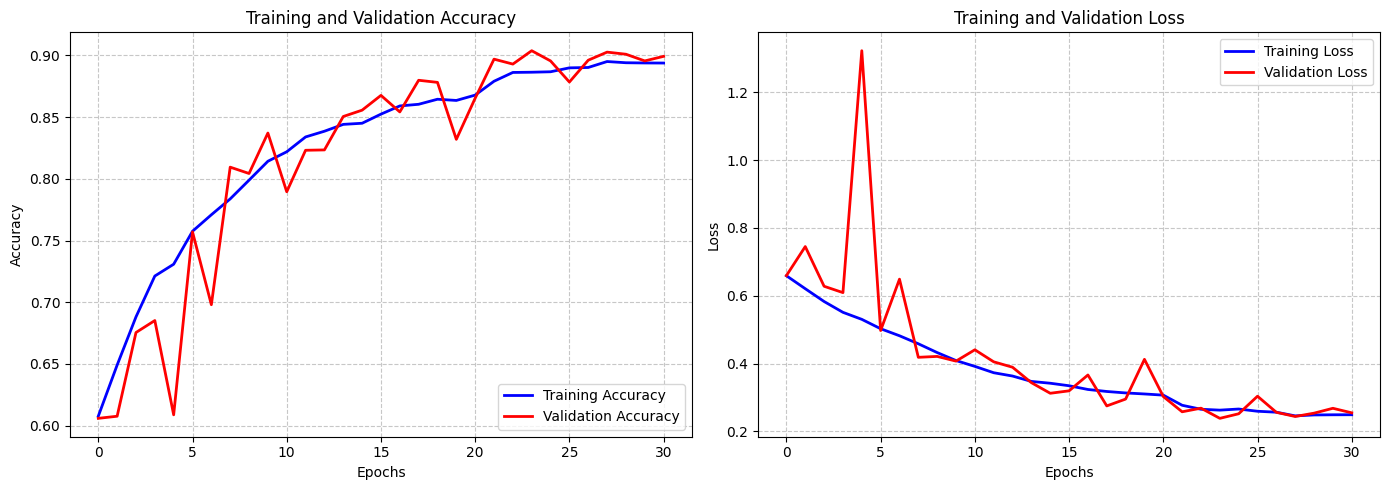

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red', linewidth=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Konversi Model**

In [19]:
import tensorflow
import tensorflowjs as tfjs

base_dir = '/content/submission'
os.makedirs(os.path.join(base_dir, 'tfjs_model'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'tflite'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'saved_model'), exist_ok=True)

saved_model_path = os.path.join(base_dir, 'saved_model')
model.export(saved_model_path)

tflite_path = os.path.join(base_dir, 'tflite', 'model.tflite')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

class_names = sorted(train_generator.class_indices.keys())
label_path = os.path.join(base_dir, 'tflite', 'label.txt')
with open(label_path, 'w') as f:
    f.write('\n'.join(class_names))


tfjs_path = os.path.join(base_dir, 'tfjs_model')
tfjs.converters.save_keras_model(model, tfjs_path)

requirements_path = os.path.join(base_dir, 'requirements.txt')
with open(requirements_path, 'w') as f:
    f.write("tensorflow\ntensorflowjs\npandas\nnumpy\nscikit-learn\nsplit-folders\n")

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_19')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135713934340368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934341136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934341328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934342288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934342096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934341520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934341904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934339600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934340752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135713934343440: TensorSpec(shape=(), dtype=tf.resource, name=None

failed to lookup keras version from the file,
    this is likely a weight only file


In [21]:
import shutil
from google.colab import files

# Mengompres folder submission
shutil.make_archive('/content/submission2', 'zip', '/content/submission')

files.download('/content/submission2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Inferensi**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step


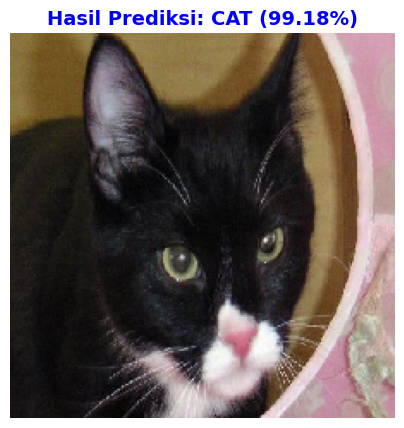

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def prediksi_gambar(model, img_path):
    img = image.load_img(img_path, target_size=(224, 224))

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_expand = np.expand_dims(img_array, axis=0)

    prediksi = model.predict(img_expand)

    if prediksi[0][0] > 0.5:
        hasil = f"DOG ({prediksi[0][0]*100:.2f}%)"
    else:
        hasil = f"CAT ({(1 - prediksi[0][0])*100:.2f}%)"


    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Hasil Prediksi: {hasil}", fontsize=14, color='blue', weight='bold')
    plt.axis('off')
    plt.show()


path_tes = '/content/pet_images_split/test/Cat/10001.jpg'

prediksi_gambar(model, path_tes)